In [2]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, fbeta_score, log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
import sys
import math
import shap
import xgboost as xgb

sys.path.insert(0, "../../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

import warnings
warnings.filterwarnings("ignore")

In [3]:
NUTS0 = 'GR'
P = 'P1'
p = P.lower()

In [5]:
file1 = f'../../data/CMacedonia/{NUTS0}_CMacedonia_WNV_Dataset_{P}_2011_2022.csv'
file2 = f'../../data/Attica/{NUTS0}_Attica_WNV_Dataset_{P}_2011_2022.csv'
file3 = f'../../data/Thessaly/{NUTS0}_Thessaly_WNV_Dataset_{P}_2011_2022.csv'

dataset1 = read_data(file1)
dataset2 = read_data(file2)
dataset3 = read_data(file3)

In [6]:
dataset1.head()

,NUTS3_ID,year,x,y,ndvi_p1,ndwi_p1,ndmi_p1,ndbi_p1,lst_mean_p1,lst_day_mean_p1,lst_night_mean_p1,lst_min_p1,lst_max_p1,prec_mean_p1,prec_acc_p1,mosq_mean_p1,mosq_sum_p1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL521,2011,22.215876,40.552658,0.252698,0.164174,0.372403,-0.372403,6.208697,9.993104,2.424290,-5.821636,3.715091,3.286000,301.706854,433.757576,1301.272727,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,31,36,30,12,12,1,6,7,12508.751326,1619.864045,10.909091,167.274024,471.994054,174.613165,0.000000,12.577415,6127.601421,866.789289,7.655240,68.916213,547.059733,11.787599,0.00000,40.400688,11806.0,44835.0,13866.0,70507.0,11360.0,44584.0,16384.0,72328.0,2016.25,5025.2,5265.4,6,[0 0 2 2 2 0]
1,EL522,2011,23.139532,40.695359,0.265538,0.022865,0.253202,-0.253202,7.444165,11.375891,3.512438,-4.746063,5.242598,2.104167,193.713711,278.692913,836.078740,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,31,30,30,10,10,1,6,6,8521.365773,2204.562938,6.102362,170.376578,294.050327,182.310346,0.006741,5.908999,5609.020284,824.307566,4.668086,44.086739,209.575010,6.368472,0.07597,10.388872,87330.0,375115.0,82051.0,544496.0,84172.0,402246.0,107376.0,593794.0,19627.51,9804.6,10058.8,10,[0 0 3 4 3 0]
2,EL523,2011,22.758634,41.016242,0.193572,0.101583,0.277345,-0.277345,6.740102,10.879505,2.600698,-5.194396,5.133956,2.543045,233.660050,279.853480,839.560440,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,31,36,30,12,12,3,5,8,10953.820049,1566.657477,6.461538,153.325412,268.365723,177.491290,0.028224,21.371767,4323.473197,1069.109617,4.638744,47.658551,207.195696,11.096824,0.15371,39.002021,5963.0,24603.0,9769.0,40335.0,5680.0,23436.0,11889.0,41005.0,1124.52,5809.2,5920.4,0,[0 0 0 0 0 0]
3,EL524,2011,22.109199,40.888821,0.252725,0.133880,0.354723,-0.354723,6.226510,10.217141,2.235878,-5.870000,4.123182,3.739724,343.464625,308.363636,925.090909,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,31,20,30,12,9,4,4,4,17893.740654,1234.209371,10.625000,142.505681,490.492098,175.009793,0.000000,16.377415,8324.265122,733.091339,9.669614,58.636781,412.361568,15.303624,0.00000,46.596750,11159.0,44537.0,14694.0,70390.0,11052.0,43212.0,17690.0,71954.0,1938.34,5025.2,5265.4,8,[0 0 0 3 5 0]
4,EL525,2011,22.441443,40.269748,0.243297,0.118603,0.330566,-0.330566,7.617001,11.342695,3.891308,-4.498444,5.272222,2.673776,245.693081,484.000000,1452.000000,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,31,36,30,12,12,1,6,7,11735.919071,971.980212,13.400000,134.587334,430.793162,170.687146,0.000000,21.108785,5383.969555,789.936868,8.881544,48.186142,455.707394,9.701413,0.00000,46.416540,10433.0,40170.0,12062.0,62665.0,10152.0,40273.0,14620.0,65045.0,1725.03,5025.2,5265.4,0,[0 0 0 0 0 0]


In [7]:
dataset2.head()

,NUTS3_ID,year,x,y,ndvi_p1,ndwi_p1,ndmi_p1,ndbi_p1,lst_mean_p1,lst_day_mean_p1,lst_night_mean_p1,lst_min_p1,lst_max_p1,prec_mean_p1,prec_acc_p1,mosq_mean_p1,mosq_sum_p1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL301,2011,23.812763,38.047451,0.190114,-0.022010,0.142095,-0.142095,11.834603,15.194800,8.474407,1.150000,9.631111,3.193722,295.331599,576.111111,1728.333333,19.750000,20.000000,45.454545,859.836137,44.0,0.0,44.0,14.833333,30.833333,30.833333,9.333333,843.0,213.0,0.0,83.792957,346.0,70.0,70.0,332.0,32,9,30,13,13,10,8,9,12606.363594,1411.887616,6.555556,192.192337,273.387005,184.906154,0.000000,18.522840,1791.885097,957.640750,5.585930,32.662113,133.294399,6.282653,0.000000,40.253180,45883.0,200375.0,47279.0,293537.0,43595.0,220412.0,60276.0,324283.0,18689.14,2605.2,3841.2,3,[0 0 0 1 1 1]
1,EL302,2011,23.685082,38.018504,0.346850,-0.177408,0.153965,-0.153965,12.589881,15.931971,9.247792,2.652222,8.874444,3.080417,284.854293,753.074074,2259.222222,21.333333,20.500000,45.555556,895.781359,46.0,1.0,45.0,15.666667,32.833333,32.833333,10.500000,806.0,204.0,0.0,83.719908,324.0,59.0,59.0,308.0,1,9,1,13,13,10,8,9,7456.110931,1302.303353,2.888889,179.452991,88.053120,178.742252,0.000000,31.947718,2186.799696,738.358541,2.619372,29.579501,38.211263,0.806462,0.000000,80.876525,38921.0,179791.0,33796.0,252508.0,36714.0,177899.0,44828.0,259441.0,7131.89,2605.2,3841.2,1,[0 0 0 0 1 0]
2,EL303,2011,23.754944,37.979104,0.178891,-0.035509,0.115201,-0.115201,12.473025,15.219113,9.726937,2.391053,10.566842,3.115267,288.063662,677.701754,2033.105263,20.458333,19.583333,44.507576,856.116584,44.0,0.0,44.0,15.500000,31.500000,31.500000,10.000000,800.0,199.0,0.0,85.292444,324.0,54.0,54.0,321.0,1,9,1,13,13,10,8,9,7725.713958,1929.044169,12.631579,217.737764,192.754855,192.653803,0.000671,19.794241,2678.000031,1043.392546,11.605605,22.744474,110.564188,10.298784,0.002009,57.297140,64868.0,377784.0,79042.0,521694.0,61544.0,388717.0,118883.0,569144.0,39021.83,2605.2,3841.2,1,[0 0 0 0 0 1]
3,EL304,2011,23.749555,37.914897,0.180365,-0.066327,0.096891,-0.096891,12.469814,15.226632,9.712996,-3.388000,10.878000,3.122400,288.749840,683.066667,2049.200000,20.666667,19.500000,42.391304,866.637529,44.0,-2.0,46.0,9.833333,31.500000,31.500000,9.833333,779.0,192.0,0.0,86.033662,317.0,46.0,46.0,317.0,32,9,30,13,13,10,8,9,3118.225377,1378.866538,7.500000,219.057236,124.615969,192.377664,0.000000,3.093557,1344.876620,533.113240,5.759051,18.911152,115.459129,9.538529,0.000000,2.890222,38993.0,183267.0,41033.0,263293.0,36789.0,199070.0,55549.0,291408.0,12606.74,2605.2,3841.2,2,[0 0 0 0 1 1]
4,EL305,2011,23.889386,38.042726,0.305248,-0.099524,0.162040,-0.162040,11.458972,14.819926,8.098017,0.098000,8.792552,3.406621,314.889622,496.831034,1490.493103,19.416667,21.000000,47.727273,855.685088,44.0,0.0,44.0,14.500000,30.500000,30.500000,9.333333,868.0,219.0,0.0,83.901842,363.0,71.0,71.0,342.0,31,30,30,10,10,1,6,6,5657.468218,2280.387151,9.272414,166.316678,277.715457,177.019093,0.000000,4.069978,3224.864575,942.777050,6.001580,52.692676,207.986089,9.842805,0.000000,3.959379,43417.0,180372.0,35396.0,259185.0,41239.0,171976.0,38828.0,252043.0,13091.44,2605.2,3841.2,20,[0 0 7 8 5 0]


In [8]:
dataset3.head()

,NUTS3_ID,year,x,y,ndvi_p1,ndwi_p1,ndmi_p1,ndbi_p1,lst_mean_p1,lst_day_mean_p1,lst_night_mean_p1,lst_min_p1,lst_max_p1,prec_mean_p1,prec_acc_p1,mosq_mean_p1,mosq_sum_p1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL611,2011,21.719540,39.504234,0.262058,0.128474,0.344166,-0.344166,6.671742,10.158842,3.184642,-4.305779,4.520588,6.112413,559.915912,468.708189,1406.124567,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,31,20,20,12,12,4,6,7,23203.497284,1321.352593,14.861592,164.292151,614.262789,178.601039,0.031194,105.223672,11862.022706,952.705549,11.851873,55.244221,454.990779,15.862025,0.185197,363.881368,17404.0,77291.0,28372.0,123067.0,16953.0,74300.0,35601.0,126854.0,3007.13,10080.6,10176.8,14,[0 0 3 8 3 0]
1,EL612,2011,22.405497,39.703383,0.227783,0.129016,0.320602,-0.320602,7.926027,12.099297,3.752758,-4.358014,5.685812,2.569974,235.698846,419.411552,1258.234657,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,31,36,30,12,12,1,6,7,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,23344.0,94158.0,25983.0,143485.0,22094.0,93589.0,31108.0,146791.0,4654.45,6268.6,6460.0,15,[0 0 4 7 4 0]
2,EL613,2011,22.869212,39.281871,0.296118,0.064122,0.301784,-0.301784,9.148190,12.441656,5.854725,-2.412083,7.174792,2.605241,240.328176,263.194444,789.583333,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,22,20,20,9,9,4,1,1,7730.943948,1546.605403,13.375000,175.419649,384.028806,172.296053,0.000000,24.597040,5039.670458,1041.036612,8.060626,63.944266,315.422916,12.169145,0.000000,91.407642,15287.0,68105.0,17655.0,101047.0,14898.0,67890.0,22944.0,105732.0,3102.99,6268.6,6460.0,1,[0 0 1 0 0 0]
3,EL611,2012,21.719540,39.504234,0.256179,-0.086326,0.127228,-0.127228,4.384951,8.557831,0.212070,-8.520173,-0.665709,3.787456,350.978756,470.478662,1411.435986,13.958333,19.250000,49.358974,841.929152,35.0,-4.0,39.0,3.833333,24.333333,24.333333,3.833333,1223.0,212.0,2.0,63.539911,472.0,91.0,91.0,472.0,31,20,20,12,12,4,6,7,23203.497284,1321.352593,14.861592,164.292151,614.262789,178.601039,0.031194,105.223672,11862.022706,952.705549,11.851873,55.244221,454.990779,15.862025,0.185197,363.881368,17312.0,77199.0,28776.0,123287.0,16778.0,73914.0,35783.0,126475.0,2698.51,10080.6,10176.8,0,[0 0 0 0 0 0]
4,EL612,2012,22.405497,39.703383,0.235517,-0.210780,-0.004328,0.004328,5.980308,11.560791,0.399826,-7.969350,-1.456137,2.174123,201.352335,512.688327,1538.064982,15.916667,22.500000,48.913043,906.249347,42.0,-4.0,46.0,10.166667,27.333333,27.333333,5.666667,928.0,123.0,4.0,50.136650,314.0,136.0,136.0,284.0,31,36,30,12,12,1,6,7,20381.214080,1439.355988,8.689531,159.540756,385.364133,180.555457,0.000000,52.856210,10627.953220,973.394450,9.072833,54.718311,362.264034,11.708138,0.000000,155.830690,23273.0,93519.0,26379.0,143171.0,22079.0,93390.0,31649.0,147118.0,4125.73,6268.6,6460.0,0,[0 0 0 0 0 0]


In [9]:
dataset = pd.concat([dataset1, dataset2, dataset3])

In [10]:
dataset

,NUTS3_ID,year,x,y,ndvi_p1,ndwi_p1,ndmi_p1,ndbi_p1,lst_mean_p1,lst_day_mean_p1,lst_night_mean_p1,lst_min_p1,lst_max_p1,prec_mean_p1,prec_acc_p1,mosq_mean_p1,mosq_sum_p1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL521,2011,22.215876,40.552658,0.252698,0.164174,0.372403,-0.372403,6.208697,9.993104,2.424290,-5.821636,3.715091,3.286000,301.706854,433.757576,1301.272727,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,31,36,30,12,12,1,6,7,12508.751326,1619.864045,10.909091,167.274024,471.994054,174.613165,0.000000,12.577415,6127.601421,866.789289,7.655240,68.916213,547.059733,11.787599,0.000000,40.400688,11806.0,44835.0,13866.0,70507.0,11360.0,44584.0,16384.0,72328.0,2016.250,5025.2,5265.4,6,[0 0 2 2 2 0]
1,EL522,2011,23.139532,40.695359,0.265538,0.022865,0.253202,-0.253202,7.444165,11.375891,3.512438,-4.746063,5.242598,2.104167,193.713711,278.692913,836.078740,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,31,30,30,10,10,1,6,6,8521.365773,2204.562938,6.102362,170.376578,294.050327,182.310346,0.006741,5.908999,5609.020284,824.307566,4.668086,44.086739,209.575010,6.368472,0.075970,10.388872,87330.0,375115.0,82051.0,544496.0,84172.0,402246.0,107376.0,593794.0,19627.510,9804.6,10058.8,10,[0 0 3 4 3 0]
2,EL523,2011,22.758634,41.016242,0.193572,0.101583,0.277345,-0.277345,6.740102,10.879505,2.600698,-5.194396,5.133956,2.543045,233.660050,279.853480,839.560440,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,31,36,30,12,12,3,5,8,10953.820049,1566.657477,6.461538,153.325412,268.365723,177.491290,0.028224,21.371767,4323.473197,1069.109617,4.638744,47.658551,207.195696,11.096824,0.153710,39.002021,5963.0,24603.0,9769.0,40335.0,5680.0,23436.0,11889.0,41005.0,1124.520,5809.2,5920.4,0,[0 0 0 0 0 0]
3,EL524,2011,22.109199,40.888821,0.252725,0.133880,0.354723,-0.354723,6.226510,10.217141,2.235878,-5.870000,4.123182,3.739724,343.464625,308.363636,925.090909,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,31,20,30,12,9,4,4,4,17893.740654,1234.209371,10.625000,142.505681,490.492098,175.009793,0.000000,16.377415,8324.265122,733.091339,9.669614,58.636781,412.361568,15.303624,0.000000,46.596750,11159.0,44537.0,14694.0,70390.0,11052.0,43212.0,17690.0,71954.0,1938.340,5025.2,5265.4,8,[0 0 0 3 5 0]
4,EL525,2011,22.441443,40.269748,0.243297,0.118603,0.330566,-0.330566,7.617001,11.342695,3.891308,-4.498444,5.272222,2.673776,245.693081,484.000000,1452.000000,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,31,36,30,12,12,1,6,7,11735.919071,971.980212,13.400000,134.587334,430.793162,170.687146,0.000000,21.108785,5383.969555,789.936868,8.881544,48.186142,455.707394,9.701413,0.000000,46.416540,10433.0,40170.0,12062.0,62665.0,10152.0,40273.0,14620.0,65045.0,1725.030,5025.2,5265.4,0,[0 0 0 0 0 0]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [11]:
dataset.drop(columns=['cases_arr'], inplace = True)

In [12]:
dataset = convert_multiple_cases(dataset, target_col='cases_total')

In [9]:
## Simple output binarization

# dataset.drop_duplicates(keep='first', inplace=True, ignore_index=True)
# dataset

In [13]:
dataset.columns

Index(['NUTS3_ID', 'year', 'x', 'y', 'ndvi_p1', 'ndwi_p1', 'ndmi_p1',
       'ndbi_p1', 'lst_mean_p1', 'lst_day_mean_p1', 'lst_night_mean_p1',
       'lst_min_p1', 'lst_max_p1', 'prec_mean_p1', 'prec_acc_p1',
       'mosq_mean_p1', 'mosq_sum_p1', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5',
       'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13',
       'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lc_prop1',
       'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4',
       'lc_type5', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'distance_to_coast_std',
       'distance_to_river_std', 'slope_mean_1km_std', 'aspect_mean_200m_std',
       'elevation_mean_1km_std', 'hillshade_mean_1km_std', 'fs_area_1km_std',
       'flow_accu_200m_std', 'males_lt15', 'males_15t64', 'males_gt65',
       'males_total', 'females_lt15', 'fema

In [15]:
print(f'Number of NUTS3 Units in dataset: {len(dataset.NUTS3_ID.unique())}')

Number of NUTS3 Units in dataset: 17


In [16]:
dsc = dataframe_describe(dataset, target_column = 'cases_total')
dsc.head(15)

,year,non-case,case,total,percentage
0,2011,2,91,93,7.96%
1,2012,8,65,73,6.24%
2,2013,9,56,65,5.56%
3,2014,16,2,18,1.54%
4,2015,17,0,17,1.45%
5,2016,17,0,17,1.45%
6,2017,17,0,17,1.45%
7,2018,2,279,281,24.04%
8,2019,5,130,135,11.55%
9,2020,7,105,112,9.58%


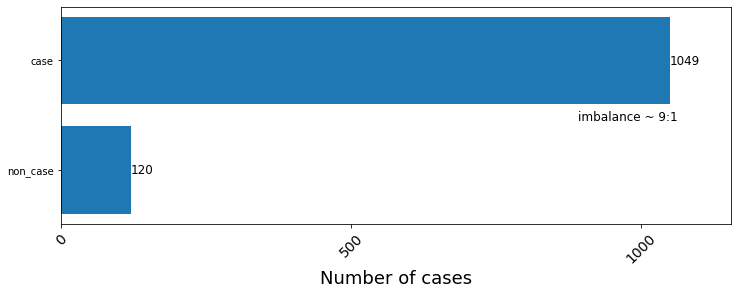

In [17]:
plot_imbalance(dataset, target_column='cases_total')

In [18]:
num_of_folds = 10
majority_class = 1
near_u = 0
smote = 0.3
depth = 3
scaler = 'minmax'
weight_multiplier = 1

years_to_remove = []
features_to_remove = ['x', 'y', 'year']

# geo_vars
# features_to_remove = ['x', 'y', 'year', 'lc_type1', 'lc_type3', 'lc_type4', 'lc_type5','lw', 'qc',]

#features_to_remove=[]
#years_to_remove = []

In [22]:
model_ft_importances = []
model_shaps = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['cases_total'] 
                                                               + features_to_remove).columns

print(feature_names)

Index(['ndvi_p1', 'ndwi_p1', 'ndmi_p1', 'ndbi_p1', 'lst_mean_p1',
       'lst_day_mean_p1', 'lst_night_mean_p1', 'lst_min_p1', 'lst_max_p1',
       'prec_mean_p1', 'prec_acc_p1', 'mosq_mean_p1', 'mosq_sum_p1', 'bio1',
       'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2',
       'lc_type3', 'lc_type4', 'lc_type5', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'distance_to_coast_std', 'distance_to_river_std',
       'slope_mean_1km_std', 'aspect_mean_200m_std', 'elevation_mean_1km_std',
       'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std',
       'males_lt15', 'males_15t64', 'males_gt65', 'males_total',
       'females_lt15', 'females_15t64', 'females_gt65', 'f

In [25]:
skf = StratifiedKFold(n_splits=num_of_folds, shuffle=True, random_state=0)
x = dataset.drop(columns = ['cases_total'])
y = dataset['cases_total']
fold = 0
  
for train_idx, test_idx in skf.split(x, y):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    #data_test = data_test.drop_duplicates(keep='first')
    if len(years_to_remove) > 0:
        data_train = data_train.loc[~data_train['year'].isin(years_to_remove)]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train, X_test, y_train, y_test, scaler, imputer = train_test_split_transform(data_train, data_test, near_u, smote, 'cases_total', scaler, majority_class, features_to_remove)

    w = calculate_scale_pos_weight(y_train, weight_multiplier)

    model = xgb.XGBClassifier(max_depth = depth, verbosity=0, seed = 0, device = 'cuda', scale_pos_weight = w, objective='binary:logistic', eval_metric = 'logloss')

    trained_model, model_shap = train_tree_model(model, X_train, y_train, explain=True)

    train, test, ft = predict_xgb_model(trained_model, X_train, y_train, X_test, y_test, data_test, day_col = None, month_col = None, spatial_col = 'NUTS3_ID')

    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    model_ft_importances.append(ft)
    model_shaps.append(model_shap)
    
    print(f"Fold: {fold} || w:{round(w,3)} || ##")
    fold = fold + 1

shap_values= np.concatenate(model_shaps, axis=0)
stacked_ft = np.stack(model_ft_importances, axis=0)
ft_values = np.mean(stacked_ft, axis=0)

Fold: 0 || w:0.149 || ##
Fold: 1 || w:0.149 || ##
Fold: 2 || w:0.149 || ##
Fold: 3 || w:0.149 || ##
Fold: 4 || w:0.149 || ##
Fold: 5 || w:0.149 || ##
Fold: 6 || w:0.149 || ##
Fold: 7 || w:0.149 || ##
Fold: 8 || w:0.149 || ##
Fold: 9 || w:0.149 || ##


In [26]:
feature_names

Index(['ndvi_p1', 'ndwi_p1', 'ndmi_p1', 'ndbi_p1', 'lst_mean_p1',
       'lst_day_mean_p1', 'lst_night_mean_p1', 'lst_min_p1', 'lst_max_p1',
       'prec_mean_p1', 'prec_acc_p1', 'mosq_mean_p1', 'mosq_sum_p1', 'bio1',
       'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2',
       'lc_type3', 'lc_type4', 'lc_type5', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'distance_to_coast_std', 'distance_to_river_std',
       'slope_mean_1km_std', 'aspect_mean_200m_std', 'elevation_mean_1km_std',
       'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std',
       'males_lt15', 'males_15t64', 'males_gt65', 'males_total',
       'females_lt15', 'females_15t64', 'females_gt65', 'f

In [27]:
len(feature_names)

67

In [19]:
bioclimatic = ['bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19']
climate = [f'min_temp_{p}', f'mean_temp_{p}', f'max_temp_{p}', f'prec_{p}']
enviromental = [f'ndvi_{p}',f'ndwi_{p}',f'ndmi_{p}',f'ndbi_{p}',f'ndvi_mean_{p}',f'ndwi_mean_{p}',f'ndmi_mean_{p}',f'ndbi_mean_{p}',f'ndvi_std_{p}',f'ndwi_std_{p}',f'ndmi_std_{p}',f'ndbi_std_{p}']
demographic = ['M_TOTAL','M_Y_LT_15','M_Y15-64','M_Y_GE65','F_TOTAL','F_Y_LT_15','F_Y15-64','F_Y_GE65']
vectors = ['culex_pipiens']
trade = ['L_TOTAL',	'UNL_TOTAL']
economic = ['MIO_EUR']

In [20]:
len(bioclimatic+climate+enviromental+demographic+vectors+trade+economic)

47

In [21]:
# shp = ft_values.shape[0]
# ft_values = ft_values.reshape(1,shp)

# fts = plot_feature_importance(ft_values, feature_names, x_label = 'Model FTs', top = 15, figure_size = (8, 4))

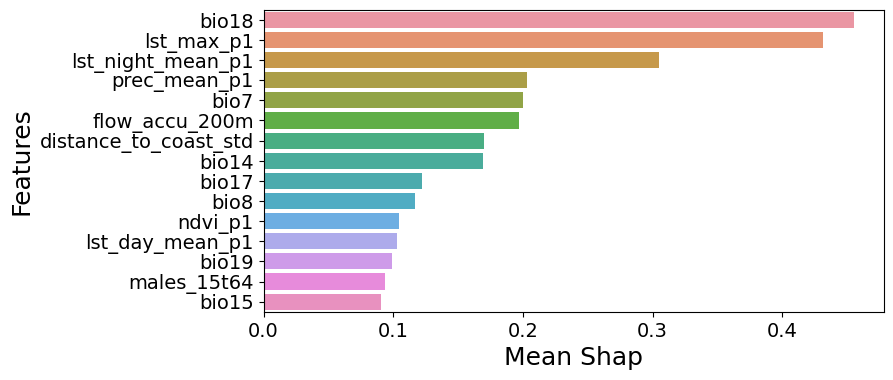

In [28]:
mean_shap = shap_values.mean(axis=0)
shp = mean_shap.shape[0]
mean_shap = mean_shap.reshape(1,shp)

shaps = plot_feature_importance(mean_shap, feature_names, x_label = 'Mean Shap', top = 15, figure_size = (8, 4))

shaps['weights_abs'] = shaps['weights'].apply(lambda x: abs(x))

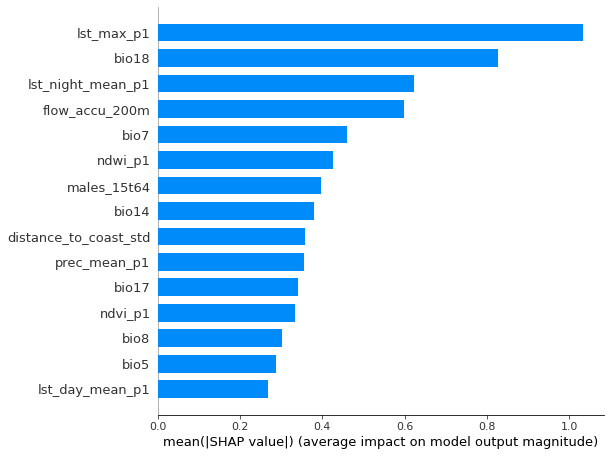

In [29]:
shap.summary_plot(shap_values, features = X_train, feature_names = feature_names, plot_type='bar', max_display=15)

,features,weights
0,bioclimatic,1.936485
1,climate,0.576598
2,enviromental,0.471505
3,demographic,0.254914
4,vectors,0.199912
6,economic,0.111650
5,trade,0.028574


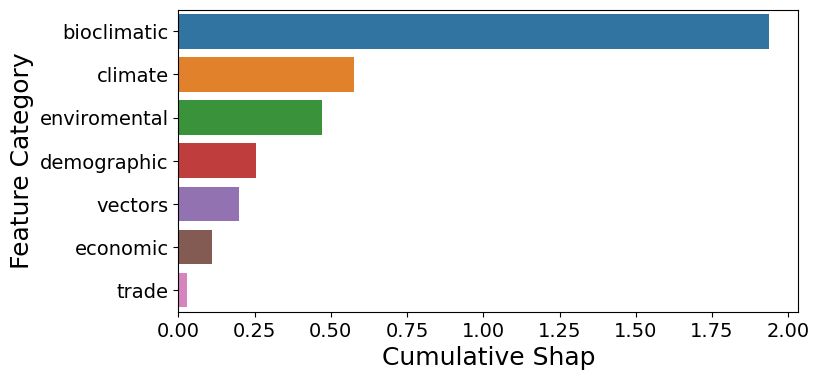

In [24]:
df_bioclimatic = shaps.loc[shaps['features'].isin(bioclimatic)].drop(columns=['weights'])
df_climate = shaps.loc[shaps['features'].isin(climate)].drop(columns=['weights'])
df_enviromental = shaps.loc[shaps['features'].isin(enviromental)].drop(columns=['weights'])
df_demographic = shaps.loc[shaps['features'].isin(demographic)].drop(columns=['weights'])
df_vectors = shaps.loc[shaps['features'].isin(vectors)].drop(columns=['weights'])
df_trade = shaps.loc[shaps['features'].isin(trade)].drop(columns=['weights'])
df_economic = shaps.loc[shaps['features'].isin(economic)].drop(columns=['weights'])

categories = {'Category': ['bioclimatic', 'climate', 'enviromental', 'demographic', 'vectors', 'trade', 'economic'], 
              'Mean_Shap': [df_bioclimatic.weights_abs.sum(),df_climate.weights_abs.sum(),df_enviromental.weights_abs.sum(),
                            df_demographic.weights_abs.sum(),df_vectors.weights_abs.sum(),df_trade.weights_abs.sum(),df_economic.weights_abs.sum()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,7)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Cumulative Shap', figure_size = (8, 4))

,features,weights
4,vectors,0.199912
1,climate,0.144150
6,economic,0.111650
0,bioclimatic,0.101920
2,enviromental,0.039292
3,demographic,0.031864
5,trade,0.014287


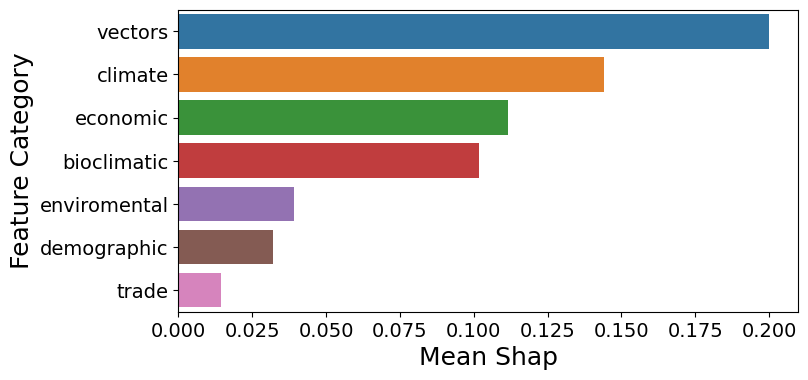

In [25]:
df_bioclimatic = shaps.loc[shaps['features'].isin(bioclimatic)].drop(columns=['weights'])
df_climate = shaps.loc[shaps['features'].isin(climate)].drop(columns=['weights'])
df_enviromental = shaps.loc[shaps['features'].isin(enviromental)].drop(columns=['weights'])
df_demographic = shaps.loc[shaps['features'].isin(demographic)].drop(columns=['weights'])
df_vectors = shaps.loc[shaps['features'].isin(vectors)].drop(columns=['weights'])
df_trade = shaps.loc[shaps['features'].isin(trade)].drop(columns=['weights'])
df_economic = shaps.loc[shaps['features'].isin(economic)].drop(columns=['weights'])

categories = {'Category': ['bioclimatic', 'climate', 'enviromental', 'demographic', 'vectors', 'trade', 'economic'], 
              'Mean_Shap': [df_bioclimatic.weights_abs.mean(),df_climate.weights_abs.mean(),df_enviromental.weights_abs.mean(),
                            df_demographic.weights_abs.mean(),df_vectors.weights_abs.mean(),df_trade.weights_abs.mean(),df_economic.weights_abs.mean()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,7)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Mean Shap', figure_size = (8, 4))

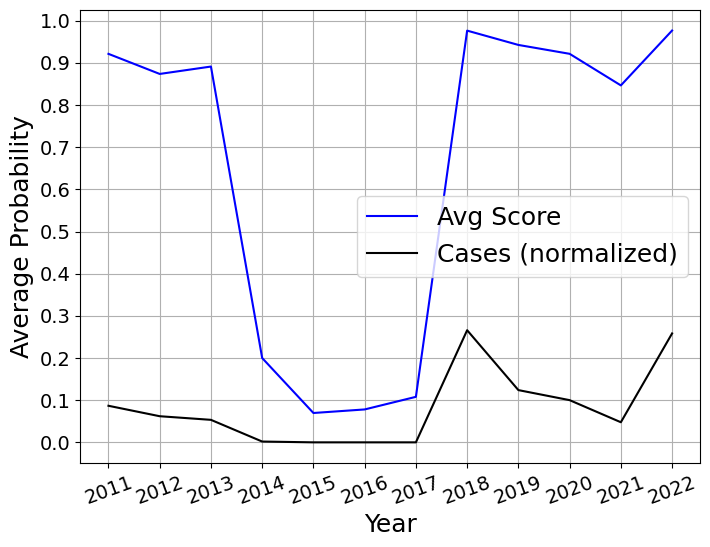

In [30]:
plot_trend_curve(results_test, score_col='score', cases=list(dsc['case']))

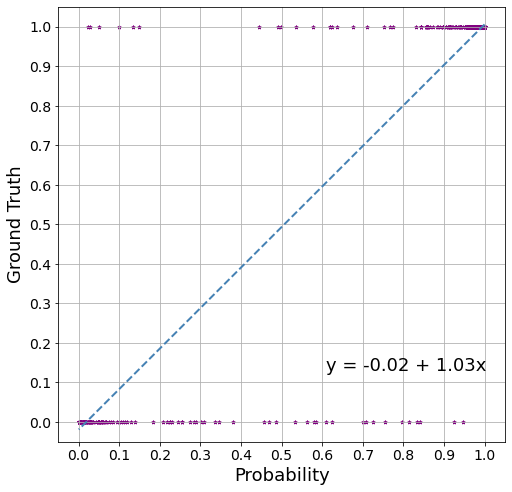

(-0.019213108909268983, 1.02503997643409)

In [31]:
plot_probability_curve(results_test, marker_size=12)

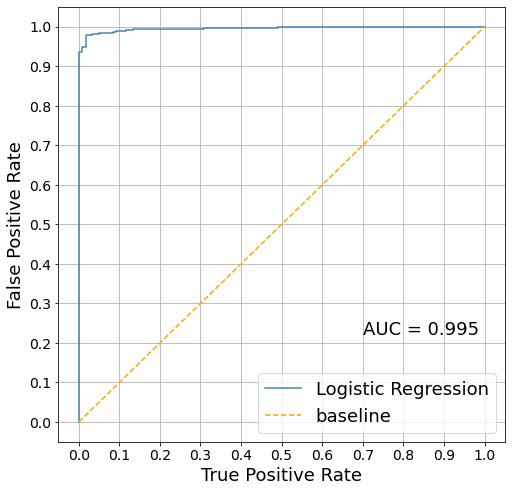

(0.0167, 0.98, 0.8428, 0.9817)

In [32]:
plot_roc_curve(results_test)

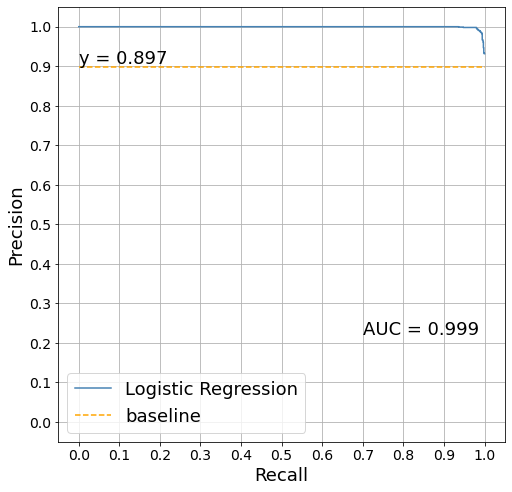

(0.9943, 0.98, 0.45, 0.9918)

In [33]:
plot_pr_curve(results_test)

In [34]:
results_train

,case,score
0,1,0.999445
1,1,0.999260
2,1,0.998817
3,1,0.998397
4,1,0.998302
...,...,...
2233,0,0.000946
2234,0,0.000382
2235,0,0.000371
2236,0,0.000309


In [35]:
logloss_train = log_loss(results_train.case, results_train.score, labels = [0,1])
logloss_train

0.033545562442445005

In [36]:
results_test

,NUTS3_ID,year,case,score
0,EL521,2021,1,0.999835
1,EL522,2022,1,0.999790
2,EL522,2022,1,0.999790
3,EL522,2022,1,0.999790
4,EL522,2022,1,0.999790
...,...,...,...,...
1164,EL306,2017,0,0.000939
1165,EL523,2017,0,0.000628
1166,EL612,2016,0,0.000452
1167,EL613,2017,0,0.000305


In [37]:
results_test['pred_01'] = results_test['score'].apply(lambda x: 1 if x>= 0.1 else 0)
results_test['pred_02'] = results_test['score'].apply(lambda x: 1 if x>= 0.2 else 0)
results_test['pred_05'] = results_test['score'].apply(lambda x: 1 if x>= 0.5 else 0)

In [38]:
results_test

,NUTS3_ID,year,case,score,pred_01,pred_02,pred_05
0,EL521,2021,1,0.999835,1,1,1
1,EL522,2022,1,0.999790,1,1,1
2,EL522,2022,1,0.999790,1,1,1
3,EL522,2022,1,0.999790,1,1,1
4,EL522,2022,1,0.999790,1,1,1
...,...,...,...,...,...,...,...
1164,EL306,2017,0,0.000939,0,0,0
1165,EL523,2017,0,0.000628,0,0,0
1166,EL612,2016,0,0.000452,0,0,0
1167,EL613,2017,0,0.000305,0,0,0


In [39]:
accuracy_01 = accuracy_score(results_test.case, results_test.pred_01)
balanced_accuracy_01 = balanced_accuracy_score(results_test.case, results_test.pred_01)
fb_score_01 = fbeta_score(results_test.case, results_test.pred_01, beta = 1, labels = [0,1], zero_division = 0)
precision_01 = precision_score(results_test.case, results_test.pred_01, labels = [0,1], zero_division = 0)
recall_01 = recall_score(results_test.case, results_test.pred_01, labels = [0,1], zero_division = 0)
logloss_01 = log_loss(results_test.case, results_test.score, labels = [0,1])

In [40]:
accuracy_02 = accuracy_score(results_test.case, results_test.pred_02)
balanced_accuracy_02 = balanced_accuracy_score(results_test.case, results_test.pred_02)
fb_score_02 = fbeta_score(results_test.case, results_test.pred_02, beta = 1, labels = [0,1], zero_division = 0)
precision_02 = precision_score(results_test.case, results_test.pred_02, labels = [0,1], zero_division = 0)
recall_02 = recall_score(results_test.case, results_test.pred_02, labels = [0,1], zero_division = 0)
logloss_02 = log_loss(results_test.case, results_test.score, labels = [0,1])

In [41]:
accuracy_05 = accuracy_score(results_test.case, results_test.pred_05)
balanced_accuracy_05 = balanced_accuracy_score(results_test.case, results_test.pred_05)
fb_score_05 = fbeta_score(results_test.case, results_test.pred_05, beta = 1, labels = [0,1], zero_division = 0)
precision_05 = precision_score(results_test.case, results_test.pred_05, labels = [0,1], zero_division = 0)
recall_05 = recall_score(results_test.case, results_test.pred_05, labels = [0,1], zero_division = 0)
logloss_05 = log_loss(results_test.case, results_test.score, labels = [0,1])

In [42]:
thr_01 = {'accuracy': accuracy_01, 'balanced_accuracy': balanced_accuracy_01, 
          'f1_score': fb_score_01, 'precision': precision_01, 'recall': recall_01, 'logloss': logloss_01}

thr_02 = {'accuracy': accuracy_02, 'balanced_accuracy': balanced_accuracy_02, 
          'f1_score': fb_score_02, 'precision': precision_02, 'recall': recall_02, 'logloss': logloss_02}

thr_05 = {'accuracy': accuracy_05, 'balanced_accuracy': balanced_accuracy_05, 
          'f1_score': fb_score_05, 'precision': precision_05, 'recall': recall_05, 'logloss': logloss_05}

In [43]:
results_df = pd.DataFrame([thr_01, thr_02, thr_05])
results_df.index = ['Threshold: 0.1', 'Threshold: 0.2', 'Threshold: 0.5']

In [44]:
results_df

,accuracy,balanced_accuracy,f1_score,precision,recall,logloss
Threshold: 0.1,0.961506,0.823570,0.978942,0.961397,0.99714,0.059918
Threshold: 0.2,0.964927,0.851307,0.980724,0.967532,0.99428,0.059918
Threshold: 0.5,0.978614,0.929044,0.988124,0.984848,0.99142,0.059918


In [45]:
print(num_of_folds)
print(depth)
print(years_to_remove)

10
3
[]
